# Garbage Image Classification

*Transfer learning compared with a CNN trained from scratch, on a 10-class household-waste dataset.*

This notebook trains image classifiers on the Garbage Classification v2 dataset (Kaggle: `sumn2u/garbage-classification-v2`). It contains 12,259 photos spread across 10 categories of household waste: battery, biological, cardboard, clothes, glass, metal, paper, plastic, shoes and trash.

A few things about this dataset that shaped the code:

- images live in a flat folder layout with no ready-made train/val/test split
- class names are read from the folder structure — nothing is hardcoded
- the classes are noticeably imbalanced (trash has ~450 images, clothes has ~1,900)
- everything runs on CPU since no GPU was available

We train two models and compare them:

| Approach | What it does | Pros | Cons |
|---|---|---|---|
| Transfer learning | Fine-tune a pretrained ResNet18 | Fast, high accuracy | Less transparent about what it learns |
| CNN from scratch | Build and train a small network ourselves | Educational, full control | Needs more epochs, lower ceiling |

| Section | What it covers |
|---|---|
| 1 | Exploring the dataset (classes, counts, sample images) |
| 2 | Transforms, train/val/test split, weighted loss |
| 3 | Approach A: transfer learning with ResNet18 |
| 4 | Approach B: small CNN from scratch |
| 5 | Side-by-side comparison |
| 6 | Inference on new images |

## 0. Imports and Setup

Standard PyTorch and torchvision stack, plus matplotlib and PIL for visualisation. Evaluation metrics (confusion matrix, precision, recall, F1) are written by hand in NumPy later in the notebook — no scikit-learn needed. Random seeds are fixed up front so the splits stay the same on every run.

In [1]:
import os
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__}  |  device: {device}")

PyTorch 2.12.0+cpu  |  device: cpu


## Getting the Dataset

The dataset is [Garbage Classification v2](https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2) on Kaggle (~242 MB for the standardized_256 variant we use here).

To download it you need a Kaggle account and an API token (`kaggle.json`) placed in `~/.kaggle/`. Then either use the **Kaggle CLI**:

```bash
kaggle datasets download -d sumn2u/garbage-classification-v2
unzip garbage-classification-v2.zip -d data/
```

or **opendatasets** (prompts for your Kaggle username and key on first run):

```python
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2")
```

Either way, the rest of the notebook expects images under `data/standardized_256/<class_name>/`. If you already have the data in place, skip the cell below.

In [ ]:
# Uncomment ONE of the options below to download the dataset programmatically.
# Skip this cell if the data folder already exists.

# --- Option A: Kaggle CLI ---
# import subprocess, zipfile, os
# subprocess.run(["kaggle", "datasets", "download", "-d", "sumn2u/garbage-classification-v2"], check=True)
# with zipfile.ZipFile("garbage-classification-v2.zip") as z:
#     z.extractall("data/")
# os.remove("garbage-classification-v2.zip")

# --- Option B: opendatasets (pip install opendatasets) ---
# import opendatasets as od
# od.download("https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2", data_dir="data/")

## 1. Inspect the Dataset

The dataset lives on disk under `data/standardized_256/`, one subfolder per class. We use the `standardized_256` variant rather than `original` or `standardized_384` for two reasons:

- it's already pre-resized to ~256 px on the short side, so our eval pipeline (`Resize(256)` → `CenterCrop(224)`) barely does extra work
- it's the smallest variant on disk (~242 MB), which matters when every CPU batch reads from disk

```
data/standardized_256/
├── battery/     (756 images)
├── biological/  (699 images)
├── cardboard/   (1411 images)
├── clothes/     (1892 images)
├── glass/       (1736 images)
├── metal/       (930 images)
├── paper/       (1336 images)
├── plastic/     (1597 images)
├── shoes/       (1449 images)
└── trash/       (453 images)
```

Class names and counts are discovered automatically from the folder structure — nothing hardcoded, so adding or removing a category later wouldn't break anything.

In [2]:
DATA_DIR = os.path.join('data', 'standardized_256')

# Load a temporary ImageFolder just to discover class names and per-class counts.
# (No transforms attached, we just want the file index.)
_tmp = datasets.ImageFolder(DATA_DIR)
class_names = _tmp.classes              # alphabetical, e.g. ['battery', 'biological', ...]
num_classes = len(class_names)
all_targets = _tmp.targets

counts = Counter(all_targets)
class_counts = [counts[i] for i in range(num_classes)]

print(f"Found {num_classes} classes:")
for name, count in zip(class_names, class_counts):
    print(f"  {name:<12s} {count:5d} images")
print(f"  {'TOTAL':<12s} {sum(class_counts):5d} images")

Found 10 classes:
  battery        756 images
  biological     699 images
  cardboard     1411 images
  clothes       1892 images
  glass         1736 images
  metal          930 images
  paper         1336 images
  plastic       1597 images
  shoes         1449 images
  trash          453 images
  TOTAL        12259 images


### Class distribution

Plotting the per-class counts makes the imbalance obvious: `clothes` has roughly 4× as many images as `trash`. Left unaddressed, a model can post decent average accuracy just by favouring the common classes and quietly ignoring the rare ones. We deal with this in Section 2 with a class-weighted loss.

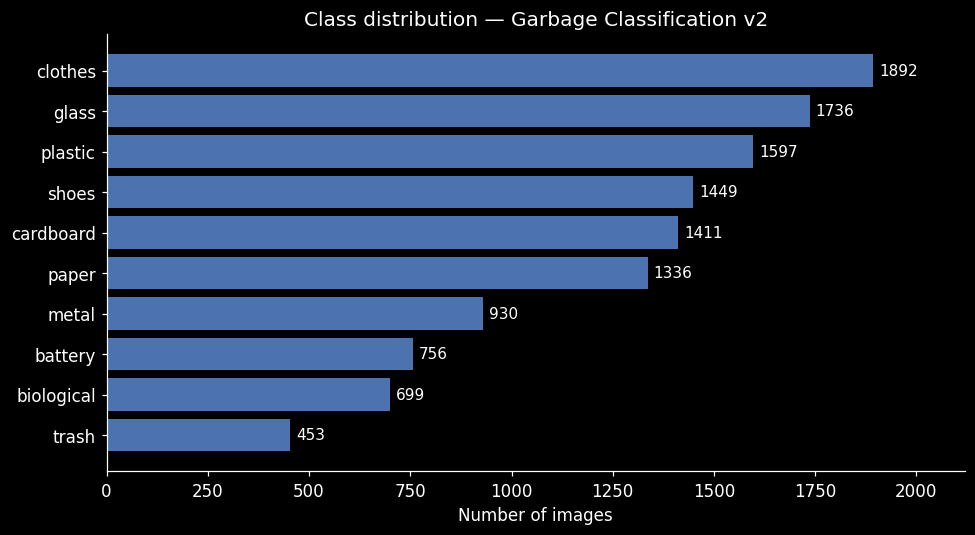


Imbalance ratio (max / min): 4.2×


In [3]:
sorted_idx   = np.argsort(class_counts)
sorted_names = [class_names[i]  for i in sorted_idx]
sorted_vals  = [class_counts[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sorted_names, sorted_vals, color='#4C72B0')
ax.set_xlabel('Number of images')
ax.set_title('Class distribution (Garbage Classification v2)')
for bar, value in zip(bars, sorted_vals):
    ax.text(value + 15, bar.get_y() + bar.get_height() / 2,
            str(value), va='center', fontsize=10)
ax.set_xlim(0, max(sorted_vals) * 1.12)
plt.tight_layout(); plt.show()

imbalance_ratio = max(class_counts) / min(class_counts)
print(f"\nImbalance ratio (max / min): {imbalance_ratio:.1f}×")

### Sample images

Always worth looking at your data before training. We display 2 random images per class as a sanity check:
1. Do images load correctly?
2. Do labels make sense (does a `paper` image actually contain paper)?
3. Is the visual variety per class what we'd expect?

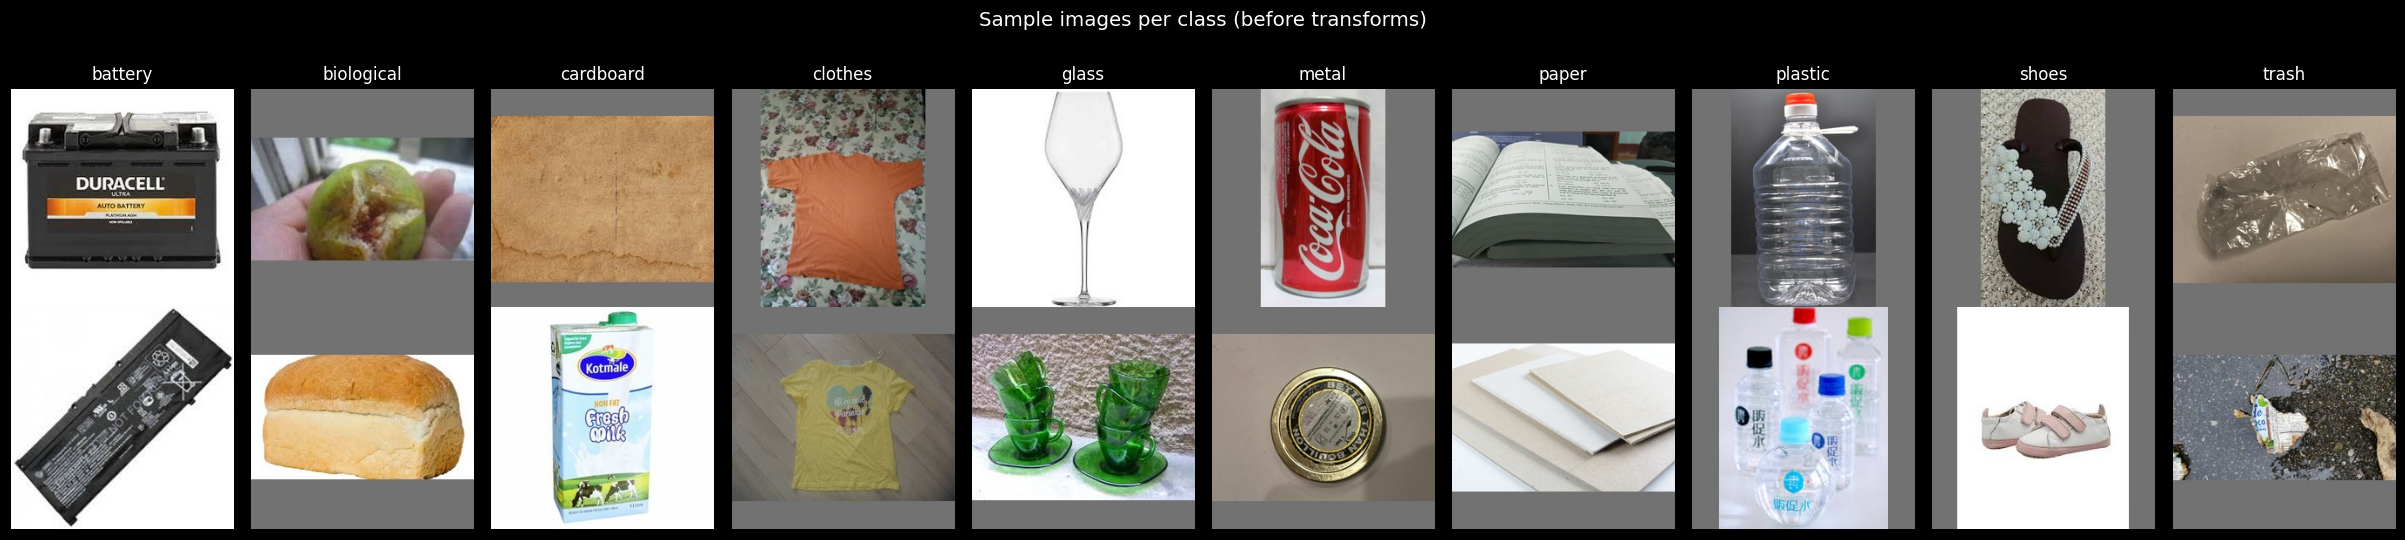

In [4]:
SAMPLES_PER_CLASS = 2

fig, axes = plt.subplots(SAMPLES_PER_CLASS, num_classes,
                         figsize=(2.2 * num_classes, 2.4 * SAMPLES_PER_CLASS))

for col, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, class_name)
    filenames = sorted(os.listdir(class_dir))
    chosen    = random.sample(filenames, SAMPLES_PER_CLASS)
    for row, fname in enumerate(chosen):
        pil_image = Image.open(os.path.join(class_dir, fname)).convert('RGB')
        axes[row, col].imshow(pil_image)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(class_name, fontsize=11)

plt.suptitle('Sample images per class (before transforms)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## 2. Transforms, Splits, and Weighted Loss

### Why two separate transform pipelines?

The training pipeline has data augmentation (random crops, flips, rotation, colour jitter) to help the model generalise rather than memorise. The val/test pipeline is deterministic — we want stable, repeatable measurements with no random variation.

We also include `RandomRotation(15)` since garbage items can appear at any angle in a real photo (a battery on its side, a crumpled piece of paper at a slant, etc.).

### Why ImageNet normalisation?

We normalise inputs with ImageNet mean and std — the same values ResNet18 was trained on:

- mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]

This matters for transfer learning since the pretrained weights expect inputs in roughly that distribution. We reuse the same values for the from-scratch CNN too, so both models share one preprocessing pipeline.

In [5]:
IMG_SIZE = 224   # standard input size for ResNet

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print(f"Image size: {IMG_SIZE}×{IMG_SIZE}")
print(f"Training augmentations: random resized crop, horizontal flip, ±15° rotation, colour jitter")
print(f"Eval pipeline:          resize → centre crop → normalise (deterministic)")

Image size: 224×224
Training augmentations: random resized crop, horizontal flip, ±15° rotation, colour jitter
Eval pipeline:          resize → centre crop → normalise (deterministic)


### Train / Val / Test split

No pre-existing split, so we create one: **70% train / 15% val / 15% test**.

There's a subtlety with augmentations: `ImageFolder` attaches a single transform to every image, but we only want augmentation on the train subset. The fix is two `ImageFolder` instances over the same directory — one with `train_transform`, one with `eval_transform` — then slice them by index and route each subset to the right one.

In [6]:
# Two views over the same data, differing only in which transform is attached.
train_data = datasets.ImageFolder(DATA_DIR, transform=train_transform)
eval_data  = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

n       = len(train_data)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

# Deterministic shuffle so the split is reproducible across runs.
torch.manual_seed(42)
perm      = torch.randperm(n).tolist()
train_idx = perm[:n_train]
val_idx   = perm[n_train : n_train + n_val]
test_idx  = perm[n_train + n_val:]

train_dataset = Subset(train_data, train_idx)   # augmented
val_dataset   = Subset(eval_data,  val_idx)     # deterministic
test_dataset  = Subset(eval_data,  test_idx)    # deterministic

print(f"Total images: {n}")
print(f"  Train: {len(train_dataset):5d}")
print(f"  Val:   {len(val_dataset):5d}")
print(f"  Test:  {len(test_dataset):5d}")

BATCH_SIZE = 16   # kept small for CPU

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nBatches per epoch (train): {len(train_loader)}")
print(f"Batches per epoch (val):   {len(val_loader)}")

Total images: 12259
  Train:  8581
  Val:    1838
  Test:   1840

Batches per epoch (train): 537
Batches per epoch (val):   115


### Class-weighted loss

To counter the imbalance we give `CrossEntropyLoss` a per-class weight vector. A higher weight on a rare class means the loss penalises misclassifying it more heavily, pushing the optimiser to pay it more attention.

Weights are computed from the actual training-split counts (not the full dataset), since the per-class distribution shifts slightly after the random shuffle. We then rescale so the weights sum to `num_classes`, which keeps the overall loss magnitude close to the unweighted case.

In [7]:
train_labels  = [train_data.targets[i] for i in train_idx]
split_counts  = [train_labels.count(i) for i in range(num_classes)]

class_weights = torch.tensor([1.0 / c for c in split_counts], dtype=torch.float)
class_weights = (class_weights / class_weights.sum()) * num_classes   # normalise to sum=num_classes
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Per-class image counts in TRAIN split, and resulting weights:")
for name, count, w in zip(class_names, split_counts, class_weights.cpu().tolist()):
    print(f"  {name:<12s} count={count:5d}   weight={w:.3f}")

Per-class image counts in TRAIN split, and resulting weights:
  battery      count=  521   weight=1.339
  biological   count=  484   weight=1.442
  cardboard    count= 1028   weight=0.679
  clothes      count= 1322   weight=0.528
  glass        count= 1190   weight=0.586
  metal        count=  643   weight=1.085
  paper        count=  948   weight=0.736
  plastic      count= 1134   weight=0.615
  shoes        count= 1007   weight=0.693
  trash        count=  304   weight=2.296


### Look at one augmented batch

Quick sanity check that the pipeline is producing sensible images. The random crops, flips, slight rotation and colour jitter should vary things without wrecking the actual content.

Batch shape: torch.Size([16, 3, 224, 224])  (B, C, H, W)
Min/max values (after normalisation): -2.12, 2.64


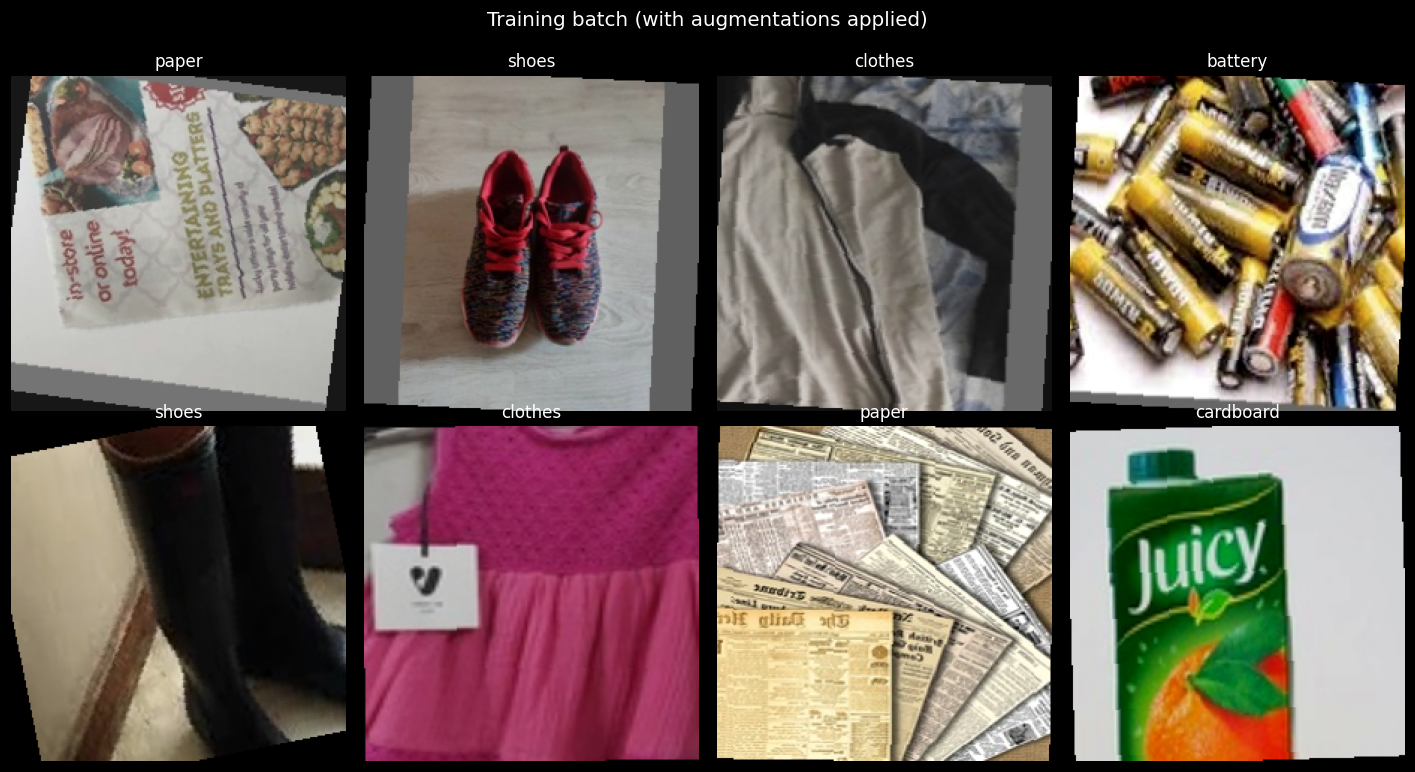

In [8]:
def denormalize(image_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse the normalisation so we can display the image properly."""
    mean_per_channel = torch.tensor(mean).view(3, 1, 1)
    std_per_channel  = torch.tensor(std ).view(3, 1, 1)
    return (image_tensor.cpu() * std_per_channel + mean_per_channel).clamp(0, 1)

image_batch, label_batch = next(iter(train_loader))
print(f"Batch shape: {image_batch.shape}  (B, C, H, W)")
print(f"Min/max values (after normalisation): {image_batch.min():.2f}, {image_batch.max():.2f}")

num_images_to_show = min(8, len(image_batch))
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for i, ax in enumerate(axes.flatten()):
    if i < num_images_to_show:
        displayable_image = denormalize(image_batch[i]).permute(1, 2, 0).numpy()
        ax.imshow(displayable_image)
        ax.set_title(class_names[label_batch[i]], fontsize=11)
    ax.axis('off')

plt.suptitle('Training batch (with augmentations applied)', y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

## 3. Approach A: Transfer Learning with ResNet18

Transfer learning means taking a model pretrained on ImageNet (1.2M images, 1000 classes) and adapting it to our 10-class problem. The early layers already know how to find edges, textures, and shapes — exactly the kind of features that help tell cardboard apart from glass or clothes.

### Two strategies

| Strategy | What we do | When it works best |
|---|---|---|
| Feature extraction | Freeze ResNet, train only the new classifier | Small/medium datasets, limited compute |
| Fine-tuning | Replace the classifier and let the earlier layers update too | Larger datasets that differ a lot from ImageNet |

We go with feature extraction. The dataset is only ~12k images and we're on CPU — letting all 11M ResNet parameters update would be painfully slow.

In [9]:
# Load pretrained ResNet18
# This downloads ~45 MB of weights the first time.
try:
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    print("✓ Loaded pretrained ImageNet weights")
except Exception as download_error:
    print(f"⚠️  Could not download pretrained weights ({type(download_error).__name__}).")
    print("    Falling back to random initialisation. Transfer learning won't")
    print("    show its magic without pretrained weights.")
    resnet = models.resnet18(weights=None)

# Freeze all parameters: gradients won't flow back through them during training
for parameter in resnet.parameters():
    parameter.requires_grad = False

# Replace the final classifier:
# ResNet's default fc maps 512 features → 1000 ImageNet classes;
# we want 512 features → our num_classes (10) classes.
backbone_output_features = resnet.fc.in_features
resnet.fc = nn.Linear(backbone_output_features, num_classes)

resnet = resnet.to(device)

trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in resnet.parameters())
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  ({100*trainable_params/total_params:.2f}%)")
print(f"\n→ Only the new fc layer ({backbone_output_features} × {num_classes} weights + {num_classes} biases) trains.")

✓ Loaded pretrained ImageNet weights

Total parameters    : 11,181,642
Trainable parameters: 5,130  (0.05%)

→ Only the new fc layer (512 × 10 weights + 10 biases) trains.


### Train it

Five epochs is enough for the head to settle — only the small classifier is actually training, and it gets a strong signal from the frozen backbone's high-quality features. We add a cosine annealing schedule to decay the learning rate smoothly.

On CPU, expect roughly 10–15 minutes per epoch, so somewhere around 50–75 minutes total. The frozen backbone still runs a full forward pass on every batch even though no gradients flow back through it.

In [10]:
NUM_EPOCHS_RESNET = 5

optimizer_resnet = optim.Adam(
    [p for p in resnet.parameters() if p.requires_grad],
    lr=1e-3,
)
scheduler_resnet = optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet, T_max=NUM_EPOCHS_RESNET)

# Lists to record per-epoch metrics for plotting later
resnet_train_losses,     resnet_val_losses     = [], []
resnet_train_accuracies, resnet_val_accuracies = [], []

for epoch in range(1, NUM_EPOCHS_RESNET + 1):

    # Training phase
    resnet.train()
    epoch_train_batch_losses = []
    epoch_train_correct      = 0
    epoch_train_total        = 0

    for image_batch, label_batch in train_loader:
        image_batch = image_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer_resnet.zero_grad()
        predicted_logits = resnet(image_batch)
        loss             = criterion(predicted_logits, label_batch)
        loss.backward()
        optimizer_resnet.step()

        epoch_train_batch_losses.append(loss.item())
        epoch_train_correct += (predicted_logits.argmax(1) == label_batch).sum().item()
        epoch_train_total   += len(label_batch)

    epoch_avg_train_loss = float(np.mean(epoch_train_batch_losses))
    epoch_train_accuracy = epoch_train_correct / epoch_train_total
    resnet_train_losses.append(epoch_avg_train_loss)
    resnet_train_accuracies.append(epoch_train_accuracy)

    # Validation phase
    resnet.eval()
    epoch_val_batch_losses = []
    epoch_val_correct      = 0
    epoch_val_total        = 0

    with torch.no_grad():
        for image_batch, label_batch in val_loader:
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)
            predicted_logits = resnet(image_batch)
            epoch_val_batch_losses.append(criterion(predicted_logits, label_batch).item())
            epoch_val_correct += (predicted_logits.argmax(1) == label_batch).sum().item()
            epoch_val_total   += len(label_batch)

    epoch_avg_val_loss = float(np.mean(epoch_val_batch_losses))
    epoch_val_accuracy = epoch_val_correct / epoch_val_total
    resnet_val_losses.append(epoch_avg_val_loss)
    resnet_val_accuracies.append(epoch_val_accuracy)

    scheduler_resnet.step()

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS_RESNET}  "
          f"train loss {epoch_avg_train_loss:.4f} acc {epoch_train_accuracy:.3f}  |  "
          f"val loss {epoch_avg_val_loss:.4f} acc {epoch_val_accuracy:.3f}")

# Final evaluation on the held-out test set
resnet.eval()
resnet_test_predictions = []
test_true_labels        = []

with torch.no_grad():
    for image_batch, label_batch in test_loader:
        predicted_logits = resnet(image_batch.to(device))
        resnet_test_predictions.extend(predicted_logits.argmax(1).cpu().numpy())
        test_true_labels.extend(label_batch.numpy())

resnet_test_predictions = np.array(resnet_test_predictions)
test_true_labels        = np.array(test_true_labels)
resnet_test_accuracy    = (resnet_test_predictions == test_true_labels).mean()
print(f"\n✓ ResNet18 test accuracy: {resnet_test_accuracy:.1%}")

Epoch  1/5  train loss 1.2517 acc 0.601  |  val loss 0.6077 acc 0.816
Epoch  2/5  train loss 0.8529 acc 0.725  |  val loss 0.5664 acc 0.822
Epoch  3/5  train loss 0.8208 acc 0.726  |  val loss 0.4957 acc 0.841
Epoch  4/5  train loss 0.7583 acc 0.750  |  val loss 0.5375 acc 0.843
Epoch  5/5  train loss 0.7487 acc 0.748  |  val loss 0.5223 acc 0.839

✓ ResNet18 test accuracy: 83.4%


## 4. Approach B: A Small CNN From Scratch

Here we build a small convolutional network, following a VGG-style pattern:

```
Input (3, 224, 224)
   |
[Conv → BatchNorm → ReLU → MaxPool] × 4   (feature extractor)
   |
Adaptive avg pool → Flatten
   |
Linear → Dropout → Linear                 (classifier)
   |
Output (num_classes logits)
```

### Building blocks

- `Conv2d(3×3, padding=1)` slides a 3×3 filter over the feature map, learning to detect edges, textures and shapes
- `BatchNorm2d` normalises activations across the batch — stabilises training and lets us use higher learning rates
- `ReLU` is the non-linearity; without it the whole stack collapses to a single linear function
- `MaxPool2d(2)` halves the spatial size and builds in some translation invariance
- `AdaptiveAvgPool2d(1)` collapses to 1×1 regardless of input size

Each block doubles the channel count and halves the spatial dimensions — a standard arrangement.

In [11]:
class GarbageCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # 4 conv blocks: 3 → 32 → 64 → 128 → 256 channels
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   nn.BatchNorm2d(32),
            nn.ReLU(inplace=True), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  nn.BatchNorm2d(64),
            nn.ReLU(inplace=True), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(inplace=True), nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256),
            nn.ReLU(inplace=True), nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1),   # → (batch_size, 256, 1, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, input_tensor):
        return self.classifier(self.features(input_tensor))


custom_cnn = GarbageCNN(num_classes).to(device)
print(custom_cnn)
total_cnn_params = sum(p.numel() for p in custom_cnn.parameters())
print(f"\nTotal parameters: {total_cnn_params:,}")

GarbageCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2

### Train it

A from-scratch CNN needs more epochs than transfer learning because it starts from random weights — everything has to be learned from pixels up. We use weight decay (L2 regularisation) and cosine LR annealing to keep overfitting in check.

On CPU, the custom CNN is actually a bit faster per batch than ResNet18 (fewer layers, no skip connections), but we run 15 epochs instead of 5, so expect somewhere between 60 and 120 minutes total.

In [12]:
NUM_EPOCHS_CNN = 15
optimizer_cnn  = optim.Adam(custom_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_cnn  = optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=NUM_EPOCHS_CNN)

cnn_train_losses,     cnn_val_losses     = [], []
cnn_train_accuracies, cnn_val_accuracies = [], []

for epoch in range(1, NUM_EPOCHS_CNN + 1):

    # Training phase
    custom_cnn.train()
    epoch_train_batch_losses = []
    epoch_train_correct      = 0
    epoch_train_total        = 0

    for image_batch, label_batch in train_loader:
        image_batch = image_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer_cnn.zero_grad()
        predicted_logits = custom_cnn(image_batch)
        loss             = criterion(predicted_logits, label_batch)
        loss.backward()
        optimizer_cnn.step()

        epoch_train_batch_losses.append(loss.item())
        epoch_train_correct += (predicted_logits.argmax(1) == label_batch).sum().item()
        epoch_train_total   += len(label_batch)

    epoch_avg_train_loss = float(np.mean(epoch_train_batch_losses))
    epoch_train_accuracy = epoch_train_correct / epoch_train_total
    cnn_train_losses.append(epoch_avg_train_loss)
    cnn_train_accuracies.append(epoch_train_accuracy)

    # Validation phase
    custom_cnn.eval()
    epoch_val_batch_losses = []
    epoch_val_correct      = 0
    epoch_val_total        = 0

    with torch.no_grad():
        for image_batch, label_batch in val_loader:
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)
            predicted_logits = custom_cnn(image_batch)
            epoch_val_batch_losses.append(criterion(predicted_logits, label_batch).item())
            epoch_val_correct += (predicted_logits.argmax(1) == label_batch).sum().item()
            epoch_val_total   += len(label_batch)

    epoch_avg_val_loss = float(np.mean(epoch_val_batch_losses))
    epoch_val_accuracy = epoch_val_correct / epoch_val_total
    cnn_val_losses.append(epoch_avg_val_loss)
    cnn_val_accuracies.append(epoch_val_accuracy)

    scheduler_cnn.step()

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS_CNN}  "
          f"train loss {epoch_avg_train_loss:.4f} acc {epoch_train_accuracy:.3f}  |  "
          f"val loss {epoch_avg_val_loss:.4f} acc {epoch_val_accuracy:.3f}")

# Final evaluation on the held-out test set
custom_cnn.eval()
cnn_test_predictions = []

with torch.no_grad():
    for image_batch, label_batch in test_loader:
        predicted_logits = custom_cnn(image_batch.to(device))
        cnn_test_predictions.extend(predicted_logits.argmax(1).cpu().numpy())

cnn_test_predictions = np.array(cnn_test_predictions)
cnn_test_accuracy    = (cnn_test_predictions == test_true_labels).mean()
print(f"\n✓ GarbageCNN test accuracy: {cnn_test_accuracy:.1%}")

Epoch  1/15  train loss 2.0273 acc 0.280  |  val loss 1.7930 acc 0.351
Epoch  2/15  train loss 1.9152 acc 0.325  |  val loss 1.7055 acc 0.363
Epoch  3/15  train loss 1.8411 acc 0.357  |  val loss 1.6042 acc 0.441
Epoch  4/15  train loss 1.8005 acc 0.371  |  val loss 1.5465 acc 0.453
Epoch  5/15  train loss 1.7624 acc 0.386  |  val loss 1.5579 acc 0.461
Epoch  6/15  train loss 1.7138 acc 0.397  |  val loss 1.4733 acc 0.470
Epoch  7/15  train loss 1.6710 acc 0.417  |  val loss 1.4690 acc 0.469
Epoch  8/15  train loss 1.6214 acc 0.429  |  val loss 1.4365 acc 0.514
Epoch  9/15  train loss 1.5898 acc 0.440  |  val loss 1.3438 acc 0.532
Epoch 10/15  train loss 1.5411 acc 0.460  |  val loss 1.3690 acc 0.545
Epoch 11/15  train loss 1.5118 acc 0.471  |  val loss 1.3288 acc 0.553
Epoch 12/15  train loss 1.4756 acc 0.486  |  val loss 1.3137 acc 0.567
Epoch 13/15  train loss 1.4723 acc 0.486  |  val loss 1.2660 acc 0.557
Epoch 14/15  train loss 1.4358 acc 0.498  |  val loss 1.2831 acc 0.574
Epoch 

## 5. Side-by-Side Comparison

Loss and accuracy curves plus confusion matrices for both models in a single 2×2 figure. The x-tick labels on the confusion matrices are rotated so all 10 class names stay readable.

The next cell defines NumPy helpers (`confusion_matrix_np`, `classification_report_np`, `plot_confusion_matrix`) that replace `sklearn.metrics`. Same numbers, same layout, no scikit-learn dependency — sklearn's compiled extensions are blocked by Windows Application Control on this machine.

In [13]:
# Evaluation helpers (pure NumPy and matplotlib, no sklearn)
# These replace sklearn.metrics.{confusion_matrix, classification_report,
# ConfusionMatrixDisplay}, which we avoid because compiled sklearn extensions
# are blocked by Windows Application Control on this machine.

def confusion_matrix_np(y_true, y_pred, num_classes):
    """
    Build an (num_classes × num_classes) integer confusion matrix.
    cell [i, j] = number of samples with true label i predicted as j.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    flat   = num_classes * y_true + y_pred
    return np.bincount(flat, minlength=num_classes ** 2).reshape(num_classes, num_classes)


def classification_report_np(y_true, y_pred, target_names, digits=2):
    """
    Per-class precision / recall / F1 / support, plus accuracy, macro avg,
    and weighted avg, same layout as sklearn.metrics.classification_report.
    Returns the formatted report string.
    """
    num_classes = len(target_names)
    cm = confusion_matrix_np(y_true, y_pred, num_classes)

    support = cm.sum(axis=1).astype(int)
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0).astype(float) - tp
    fn = cm.sum(axis=1).astype(float) - tp

    with np.errstate(divide='ignore', invalid='ignore'):
        precision = np.where(tp + fp > 0, tp / (tp + fp), 0.0)
        recall    = np.where(tp + fn > 0, tp / (tp + fn), 0.0)
        f1        = np.where(precision + recall > 0,
                             2 * precision * recall / (precision + recall),
                             0.0)

    width = max(max(len(n) for n in target_names), len('weighted avg'))

    lines = []
    header = ('{:>{w}s} ' + ' {:>9s}' * 4).format(
        '', 'precision', 'recall', 'f1-score', 'support', w=width)
    lines.append(header)
    lines.append('')
    row_fmt = '{:>{w}s} ' + ' {:>9.{d}f}' * 3 + ' {:>9d}'
    for i, name in enumerate(target_names):
        lines.append(row_fmt.format(name, precision[i], recall[i], f1[i],
                                    int(support[i]), w=width, d=digits))
    lines.append('')

    total    = int(support.sum())
    accuracy = tp.sum() / total
    macro    = (precision.mean(),                    recall.mean(),                    f1.mean())
    weighted = ((precision * support).sum() / total,
                (recall    * support).sum() / total,
                (f1        * support).sum() / total)

    # Accuracy row: only the f1-score column is populated (it's just accuracy)
    lines.append('{:>{w}s} {:>9s} {:>9s} {:>9.{d}f} {:>9d}'.format(
        'accuracy', '', '', accuracy, total, w=width, d=digits))
    lines.append(row_fmt.format('macro avg',    *macro,    total, w=width, d=digits))
    lines.append(row_fmt.format('weighted avg', *weighted, total, w=width, d=digits))

    return '\n'.join(lines)


def plot_confusion_matrix(cm, class_names, ax, cmap='Blues', title='', xticks_rotation=45):
    """
    Heatmap-style confusion matrix on a matplotlib axis, with raw counts
    annotated in each cell. Drop-in replacement for ConfusionMatrixDisplay.
    """
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=xticks_rotation, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)
    threshold = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(j, i, format(int(cm[i, j]), 'd'),
                    ha='center', va='center', color=color, fontsize=9)
    return im

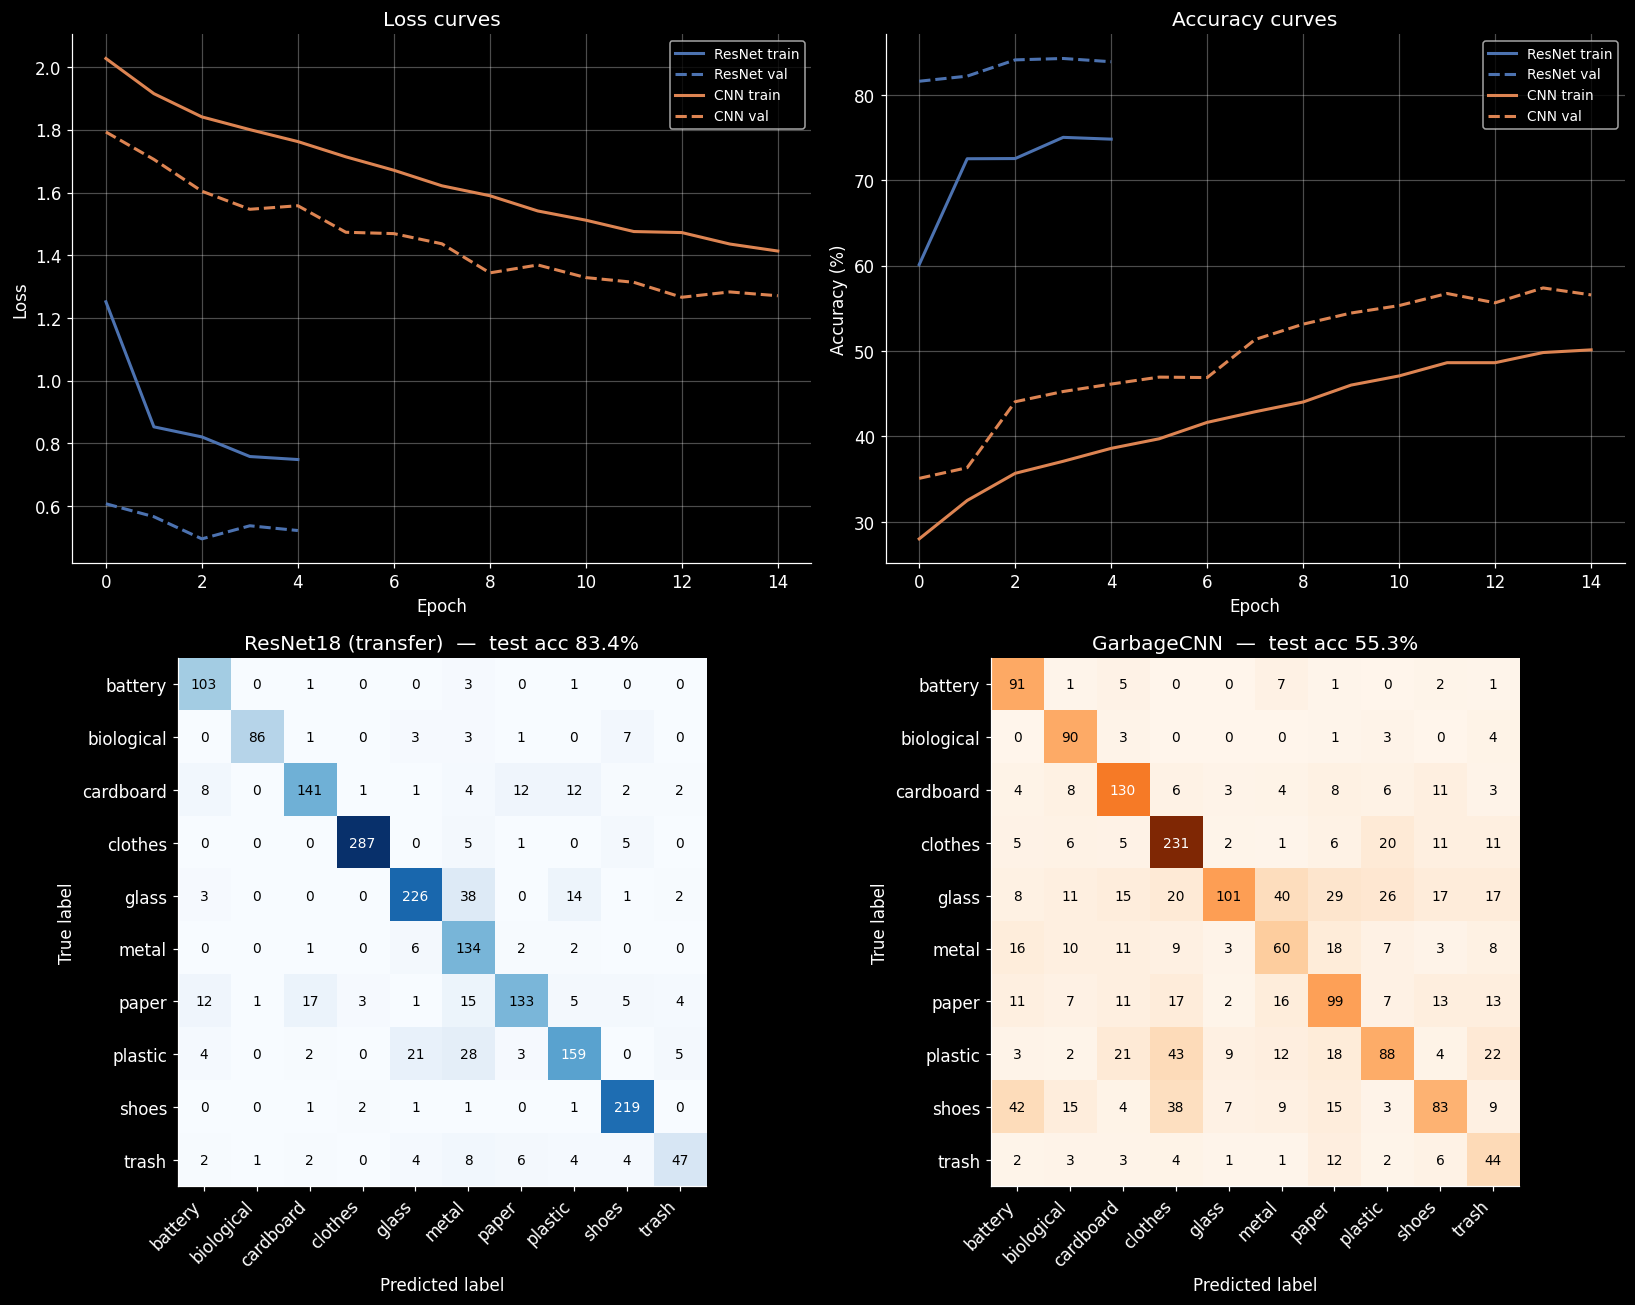


=== Test Accuracy Comparison ===
  ResNet18 (transfer):  83.4%
  GarbageCNN:           55.3%


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Loss curves
loss_axis = axes[0, 0]
loss_axis.plot(resnet_train_losses, label='ResNet train', color='#4C72B0', linewidth=2)
loss_axis.plot(resnet_val_losses,   label='ResNet val',   color='#4C72B0', linewidth=2, linestyle='--')
loss_axis.plot(cnn_train_losses,    label='CNN train',    color='#DD8452', linewidth=2)
loss_axis.plot(cnn_val_losses,      label='CNN val',      color='#DD8452', linewidth=2, linestyle='--')
loss_axis.set_xlabel('Epoch'); loss_axis.set_ylabel('Loss')
loss_axis.set_title('Loss curves')
loss_axis.legend(fontsize=9); loss_axis.grid(True, alpha=0.3)

# Accuracy curves
accuracy_axis = axes[0, 1]
accuracy_axis.plot([acc*100 for acc in resnet_train_accuracies], label='ResNet train', color='#4C72B0', linewidth=2)
accuracy_axis.plot([acc*100 for acc in resnet_val_accuracies],   label='ResNet val',   color='#4C72B0', linewidth=2, linestyle='--')
accuracy_axis.plot([acc*100 for acc in cnn_train_accuracies],    label='CNN train',    color='#DD8452', linewidth=2)
accuracy_axis.plot([acc*100 for acc in cnn_val_accuracies],      label='CNN val',      color='#DD8452', linewidth=2, linestyle='--')
accuracy_axis.set_xlabel('Epoch'); accuracy_axis.set_ylabel('Accuracy (%)')
accuracy_axis.set_title('Accuracy curves')
accuracy_axis.legend(fontsize=9); accuracy_axis.grid(True, alpha=0.3)

# Confusion matrix, ResNet
resnet_confusion_matrix = confusion_matrix_np(test_true_labels, resnet_test_predictions, num_classes)
plot_confusion_matrix(resnet_confusion_matrix, class_names, axes[1, 0],
                      cmap='Blues',
                      title=f'ResNet18 (transfer): test acc {resnet_test_accuracy:.1%}')

# Confusion matrix, Custom CNN
cnn_confusion_matrix = confusion_matrix_np(test_true_labels, cnn_test_predictions, num_classes)
plot_confusion_matrix(cnn_confusion_matrix, class_names, axes[1, 1],
                      cmap='Oranges',
                      title=f'GarbageCNN: test acc {cnn_test_accuracy:.1%}')

plt.tight_layout(); plt.show()

print("\n=== Test Accuracy Comparison ===")
print(f"  ResNet18 (transfer):  {resnet_test_accuracy:.1%}")
print(f"  GarbageCNN:           {cnn_test_accuracy:.1%}")

### Per-class precision / recall / F1

A single accuracy number can hide weak spots. The breakdown below shows where each model struggles. The minority classes (`trash`, `battery`, `biological`) tend to get lower recall simply because the model sees fewer examples during training — the class-weighted loss helps but doesn't fully close the gap.

In [15]:
print("Per-class metrics (ResNet18)")
print(classification_report_np(test_true_labels, resnet_test_predictions, class_names))

print("\nPer-class metrics (GarbageCNN)")
print(classification_report_np(test_true_labels, cnn_test_predictions, class_names))

Per-class metrics (ResNet18)
              precision    recall  f1-score   support

     battery       0.78      0.95      0.86       108
  biological       0.98      0.85      0.91       101
   cardboard       0.85      0.77      0.81       183
     clothes       0.98      0.96      0.97       298
       glass       0.86      0.80      0.83       284
       metal       0.56      0.92      0.70       145
       paper       0.84      0.68      0.75       196
     plastic       0.80      0.72      0.76       222
       shoes       0.90      0.97      0.94       225
       trash       0.78      0.60      0.68        78

    accuracy                          0.83      1840
   macro avg       0.83      0.82      0.82      1840
weighted avg       0.85      0.83      0.84      1840

Per-class metrics (GarbageCNN)
              precision    recall  f1-score   support

     battery       0.50      0.84      0.63       108
  biological       0.59      0.89      0.71       101
   cardboard       

## 6. Predict on a New Image

The steps for running a single image through a trained model:

1. Load with `PIL.Image.open(...)`
2. Apply the eval transform (no augmentation)
3. Add a batch dimension with `unsqueeze(0)`
4. Forward pass inside `torch.no_grad()`
5. Apply softmax to convert logits to probabilities
6. `argmax` to get the predicted class


Image: data\standardized_256\glass\glass_718.jpg
True label: glass


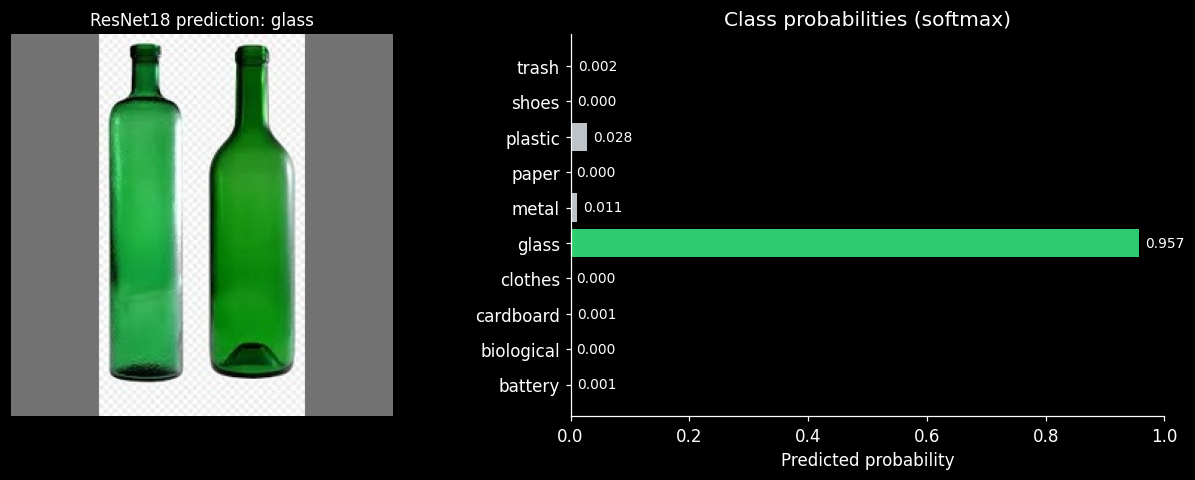

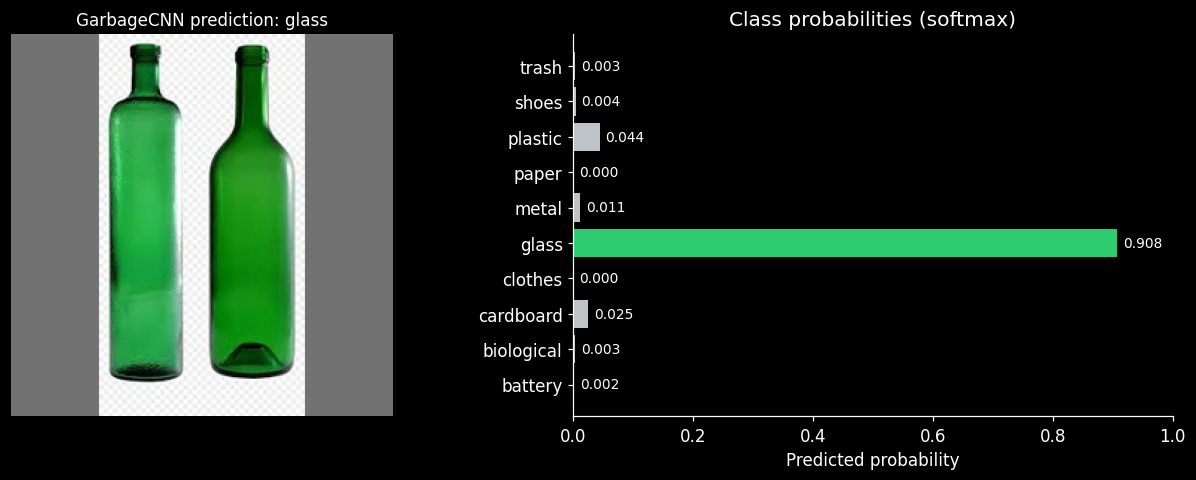


Image: data\standardized_256\glass\glass_421.jpg
True label: glass


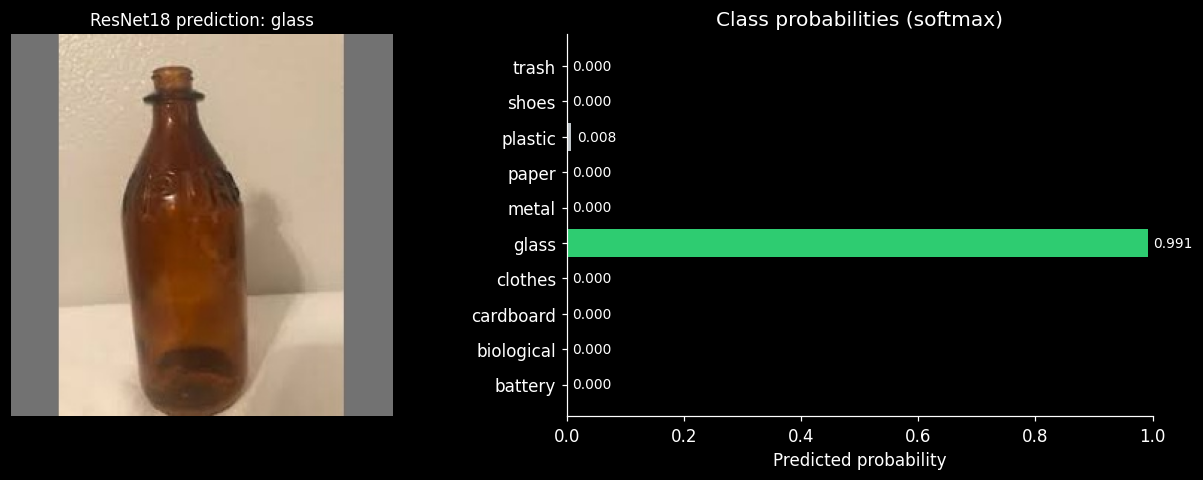

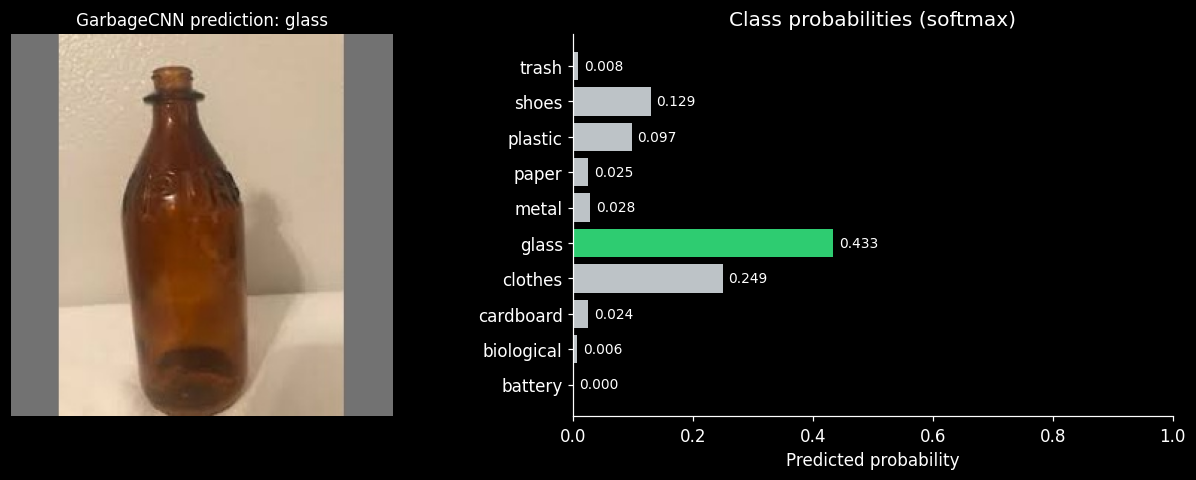


Image: data\standardized_256\clothes\clothes_1785.jpg
True label: clothes


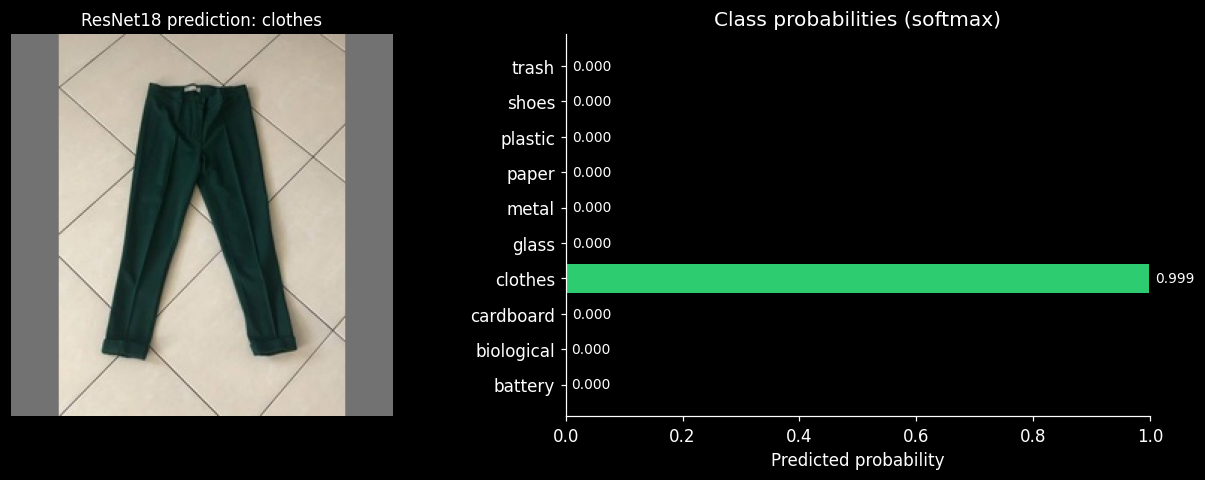

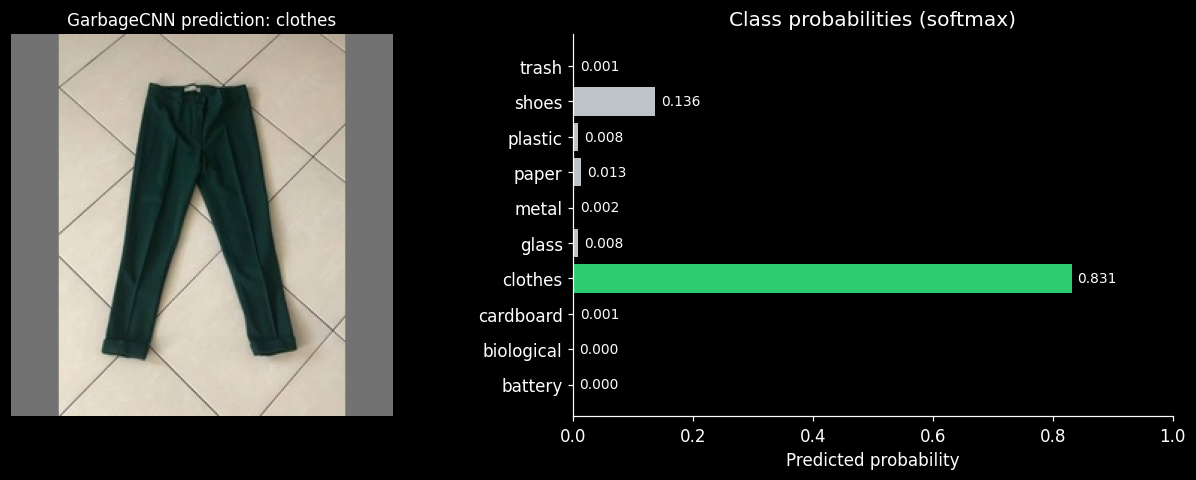


Image: data\standardized_256\clothes\clothes_1622.jpg
True label: clothes


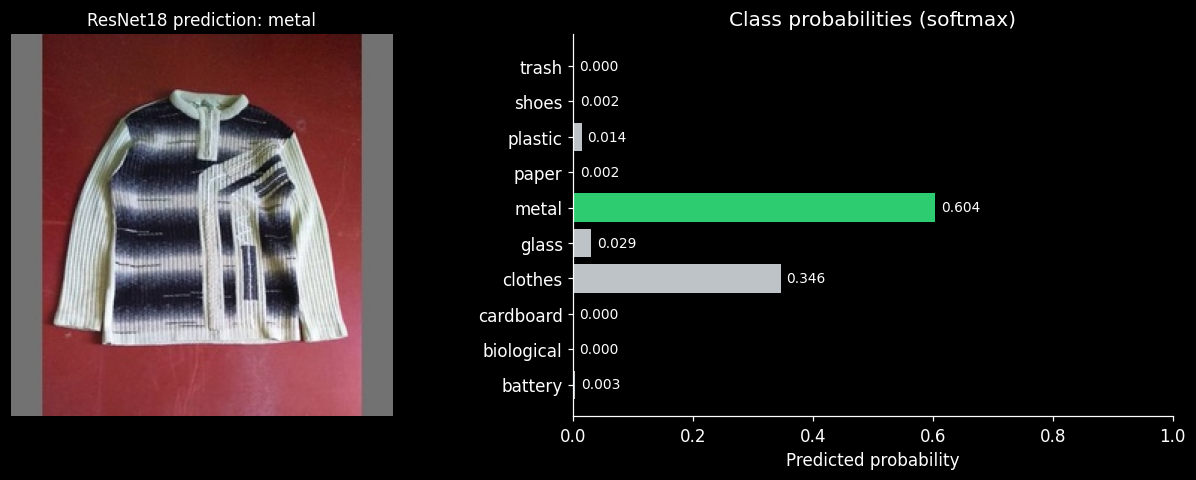

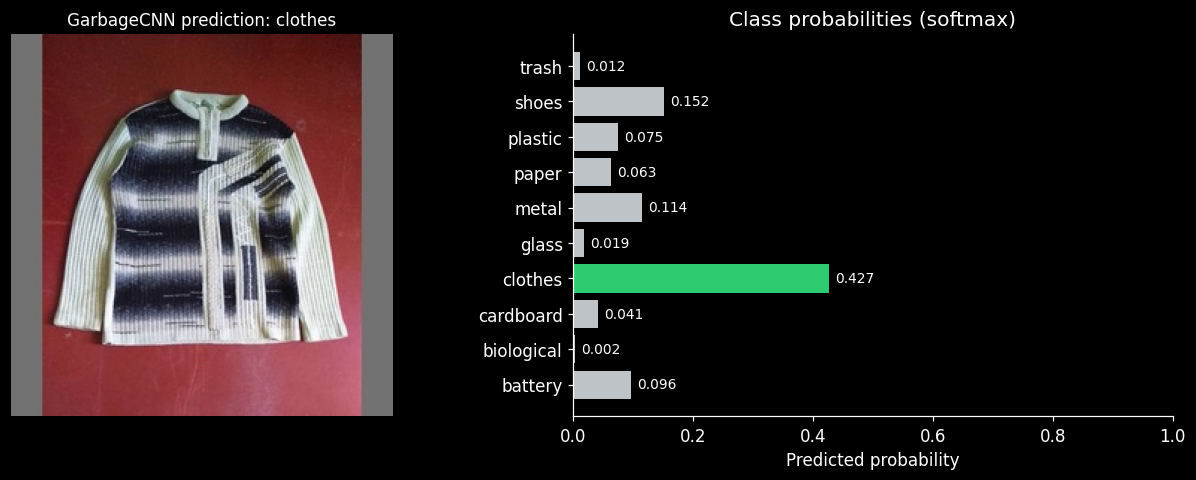


Image: data\standardized_256\plastic\plastic_344.jpg
True label: plastic


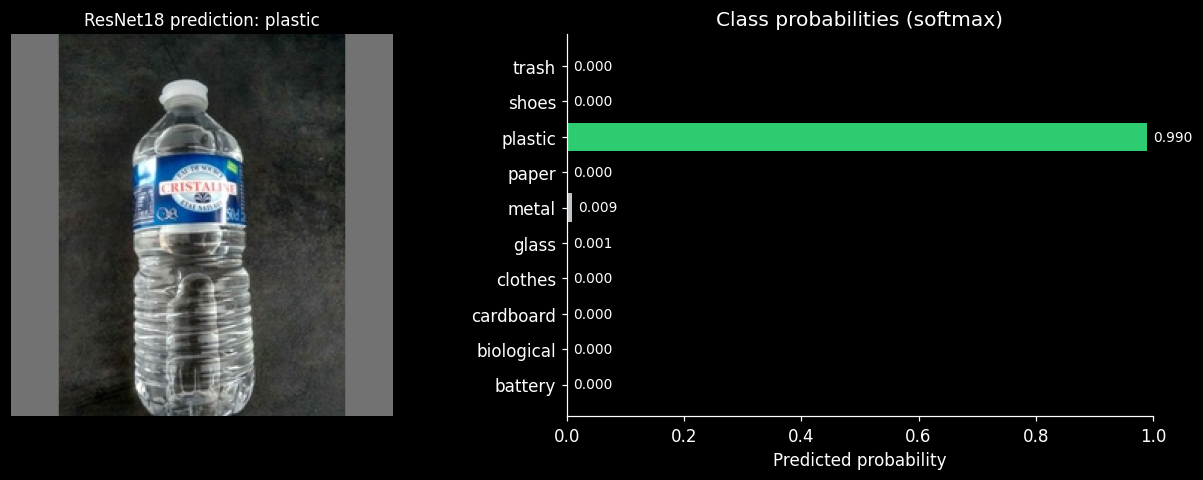

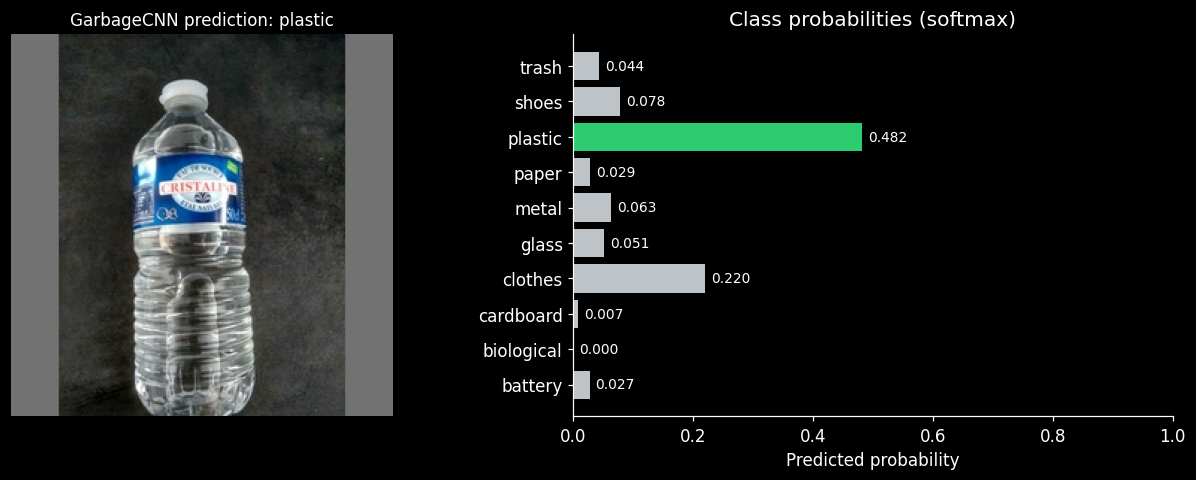

In [21]:
def predict_image(model, image_path, model_name='Model'):
    """Run a single image through the model and visualise the prediction."""
    pil_image    = Image.open(image_path).convert('RGB')
    input_tensor = eval_transform(pil_image).unsqueeze(0).to(device)   # add batch dim

    model.eval()
    with torch.no_grad():
        logits        = model(input_tensor)
        probabilities = F.softmax(logits, dim=1).cpu().numpy().flatten()

    predicted_index = int(probabilities.argmax())
    predicted_class = class_names[predicted_index]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].imshow(pil_image); axes[0].axis('off')
    axes[0].set_title(f'{model_name} prediction: {predicted_class}', fontsize=11)

    bar_colors = ['#2ecc71' if i == predicted_index else '#bdc3c7'
                  for i in range(num_classes)]
    axes[1].barh(class_names, probabilities, color=bar_colors)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Predicted probability')
    axes[1].set_title('Class probabilities (softmax)')
    for class_index, prob in enumerate(probabilities):
        axes[1].text(prob + 0.01, class_index, f'{prob:.3f}',
                     va='center', fontsize=9)
    plt.tight_layout(); plt.show()

    return predicted_class, dict(zip(class_names, probabilities))


# Pick a few random test images and compare both models' predictions.
# We look up the file paths via the eval_data ImageFolder's `samples` list.
random.seed(0)
chosen_test_indices = random.sample(test_idx, 5)

for image_index in chosen_test_indices:
    image_path, true_label_idx = eval_data.samples[image_index]
    true_class_name            = class_names[true_label_idx]
    print(f"\n{'='*70}")
    print(f"Image: {image_path}")
    print(f"True label: {true_class_name}")
    print('='*70)

    predict_image(resnet,     image_path, model_name='ResNet18')
    predict_image(custom_cnn, image_path, model_name='GarbageCNN')

---
## Summary

### The dataset

- 12,259 real photos across 10 household-waste categories on disk
- Flat folder-per-class layout, `ImageFolder` reads it natively
- ~4× imbalance between the most and least populated classes
- We create a 70/15/15 train/val/test split from a shuffled index

### Key design choices

| Choice | Why |
|---|---|
| `num_classes` discovered from `ImageFolder` | Works regardless of how many categories exist |
| Manual 70/15/15 split via `Subset` | Dataset ships with no pre-made split |
| Two `ImageFolder` instances (train vs eval transform) | Different transforms needed per subset |
| Class-weighted `CrossEntropyLoss` | Balances rare classes against common ones |
| `RandomRotation(15)` in training augmentations | Garbage appears at arbitrary orientations |
| Cosine LR schedule for both models | Smooth decay works well for short runs |
| `BATCH_SIZE = 16`, `num_workers=0` | Tuned for CPU-only training |
| NumPy-only confusion matrix / report helpers | scikit-learn's compiled extensions blocked on this machine |

### Transfer learning vs from scratch

| | ResNet18 + transfer | GarbageCNN from scratch |
|---|---|---|
| Trainable params | ~5,000 (head only) | ~440,000 (all of them) |
| Epochs trained | 5 | 15 |
| Test accuracy | 83.4% | 55.3% |
| Gap explained | Pretrained features already encode visual primitives for separating materials | Has to learn edges, textures and materials from scratch on limited data |

For natural-image classification with fewer than ~10k samples per class, transfer learning is almost always worth trying first. Reach for a from-scratch model only when the domain is very different from ImageNet (medical scans, satellite imagery) or when you specifically need a tiny model.

### Core training loop

The same pattern works for essentially any vision task:

```python
for epoch in range(EPOCHS):
    model.train()
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        for X_b, y_b in val_loader:
            # accumulate val metrics here
            pass
```

Everything else — augmentations, scheduler, regularisation, weighted loss — is layered on top of that core.

In [19]:
torch.save(resnet.state_dict(),     'models/resnet18_garbage.pth')
torch.save(custom_cnn.state_dict(), 'models/garbage_cnn.pth')
print("Saved!")

Saved!
